# Differential Logic Part 2: Implies and Equivalence

blog post: https://fualsan.github.io/posts/differential-logic-part-2/


In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.25'

%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp

from functools import partial

from logic_utils import print_binary, plot_norm_functions
from triangular_norms import diff_and, diff_or, diff_not

In [2]:
# x1: True, True, False, False
x1 = jnp.array((0.95, 0.88, 0.21, 0.16))
# x2: True, False, True, False
x2 = jnp.array((0.71, 0.02, 0.99, 0.10))

In [3]:
print(x1)
print(x2)

[0.95 0.88 0.21 0.16]
[0.71 0.02 0.99 0.1 ]


In [4]:
print_binary(x1)

0.95 --> 1 (True)
0.88 --> 1 (True)
0.21 --> 0 (False)
0.16 --> 0 (False)


In [5]:
print_binary(x2)

0.71 --> 1 (True)
0.02 --> 0 (False)
0.99 --> 1 (True)
0.10 --> 0 (False)


## Implies 
$X_1 \rightarrow X_2 = \neg X_1 \lor X_2 $

In [6]:
def diff_implies(x1, x2, name_tconorm):
    return diff_or(diff_not(x1), x2, name_tconorm)

diff_implies_maximum  = partial(diff_implies, name_tconorm='maximum')
diff_implies_prob_sum = partial(diff_implies, name_tconorm='probabilistic_sum')
diff_implies_bounded  = partial(diff_implies, name_tconorm='bounded')

In [7]:
x_imp = diff_implies_maximum(x1, x2)
print_binary(x_imp)

0.71 --> 1 (True)
0.12 --> 0 (False)
0.99 --> 1 (True)
0.84 --> 1 (True)


In [8]:
x_imp = diff_implies_prob_sum(x1, x2)
print_binary(x_imp)

0.72 --> 1 (True)
0.14 --> 0 (False)
1.00 --> 1 (True)
0.86 --> 1 (True)


In [9]:
x_imp = diff_implies_bounded(x1, x2)
print_binary(x_imp)

0.76 --> 1 (True)
0.14 --> 0 (False)
1.00 --> 1 (True)
0.94 --> 1 (True)


## Equivalence

$X_1 \leftrightarrow X_2 = (X_1 \rightarrow X_2) \land (X_2 \rightarrow X_1)$ 

In [10]:
def diff_equivalence(x1, x2, name_tnorm, name_tconorm):
    return diff_and(diff_implies(x1, x2, name_tconorm), diff_implies(x2, x1, name_tconorm), name_tnorm)

diff_equivalence_product_prob_sum = partial(diff_equivalence, name_tnorm='product', name_tconorm='probabilistic_sum')

In [11]:
# notice that if truth is around 0.5, equivalence is also low ..., 
# this shows our intioun of values closer to 0.0 and 1.0 ...
x_equiv = diff_equivalence_product_prob_sum(x1, x2)
print_binary(x_equiv)

0.70 --> 1 (True)
0.14 --> 0 (False)
0.22 --> 0 (False)
0.78 --> 1 (True)


## Implies Plots

In [12]:
NUM_SAMPLES = 100
x1 = jnp.linspace(0.0, 1.0, NUM_SAMPLES)
x2 = jnp.linspace(0.0, 1.0, NUM_SAMPLES)

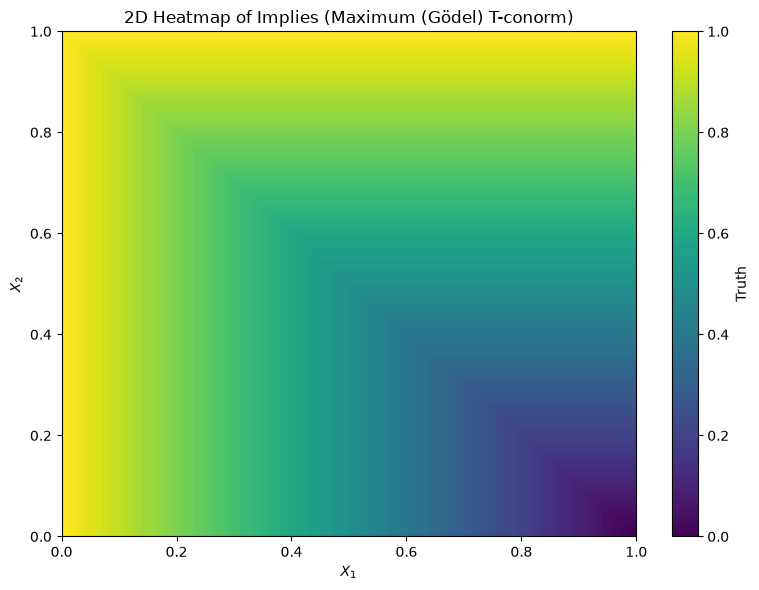

In [13]:
plot_norm_functions(x1, x2, diff_implies_maximum, 'Implies (Maximum (Gödel) T-conorm)', 'implies_maximum')

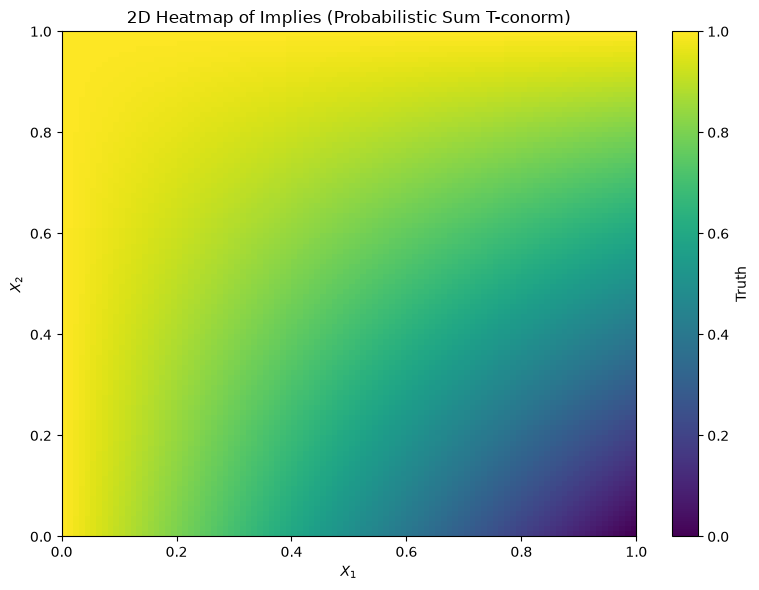

In [14]:
plot_norm_functions(x1, x2, diff_implies_prob_sum, 'Implies (Probabilistic Sum T-conorm)', 'implies_sum')

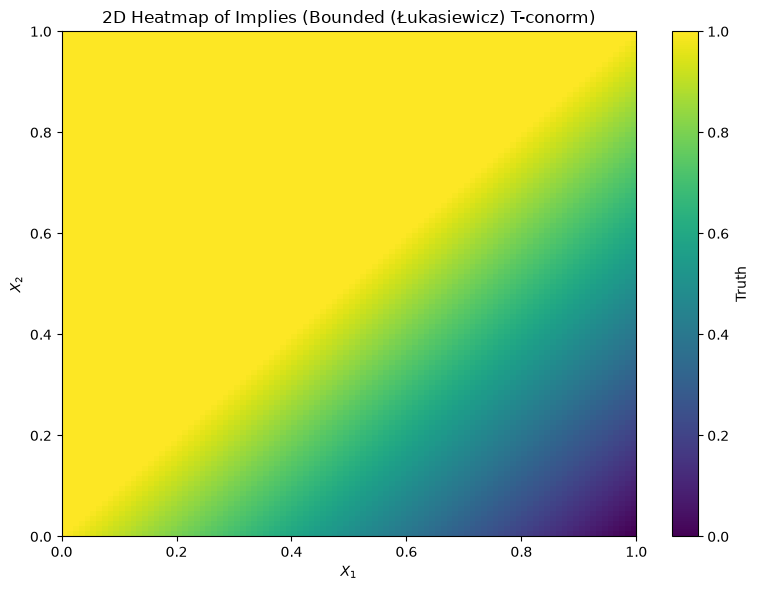

In [15]:
plot_norm_functions(x1, x2, diff_implies_bounded, 'Implies (Bounded (Łukasiewicz) T-conorm)', 'implies_bounded')

## Equivalence Plots

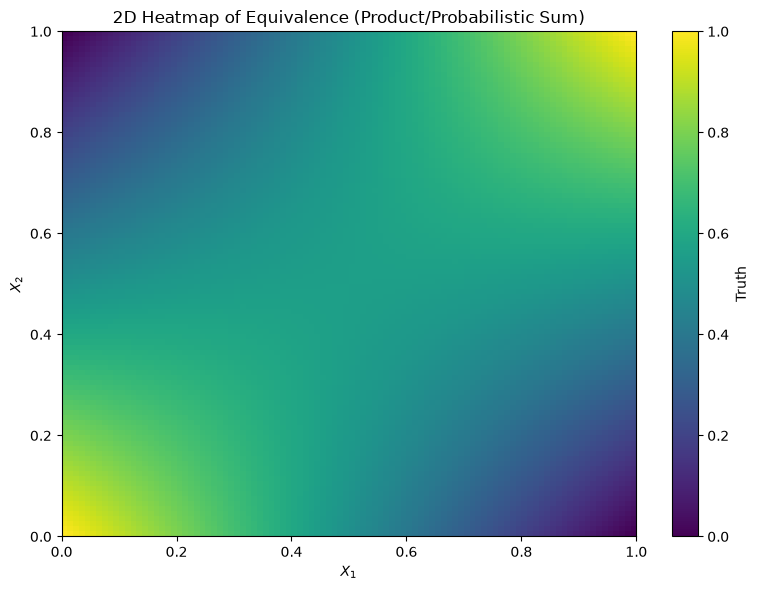

In [16]:
plot_norm_functions(x1, x2, diff_equivalence_product_prob_sum, 'Equivalence (Product/Probabilistic Sum)', 'equivalence_product_prob_sum')